In [83]:
import yfinance as yf
import numpy as np
import pandas as pd

# S&P500 지수 다운로드 (티커: ^GSPC)
data = yf.download("^GSPC", start="2020-01-01")
returns = data.loc[:, pd.IndexSlice[:, "^GSPC", :]]
returns.columns = returns.columns.droplevel(1)  # ^GSPC 레벨 제거

# 로그 변화율 계산
returns["logchange"] = np.log(returns["Close"] / returns["Close"].shift(1))

# 비율 변화량 계산 (pct_change 사용)
returns["change"] = returns["Close"].pct_change()

# change를 logchange로부터 복구
returns["test"] = np.exp(returns["logchange"]) - 1

# 불필요한 NaN 값 제거
returns = returns.dropna()

# 필요한 열만 선택
returns = returns[["Close", "change", "logchange", "test"]]

print(returns)

[*********************100%***********************]  1 of 1 completed

Price             Close    change  logchange      test
Date                                                  
2020-01-03  3234.850098 -0.007060  -0.007085 -0.007060
2020-01-06  3246.280029  0.003533   0.003527  0.003533
2020-01-07  3237.179932 -0.002803  -0.002807 -0.002803
2020-01-08  3253.050049  0.004902   0.004890  0.004902
2020-01-09  3274.699951  0.006655   0.006633  0.006655
...                 ...       ...        ...       ...
2025-05-02  5686.669922  0.014727   0.014619  0.014727
2025-05-05  5650.379883 -0.006382  -0.006402 -0.006382
2025-05-06  5606.910156 -0.007693  -0.007723 -0.007693
2025-05-07  5631.279785  0.004346   0.004337  0.004346
2025-05-08  5663.939941  0.005800   0.005783  0.005800

[1344 rows x 4 columns]


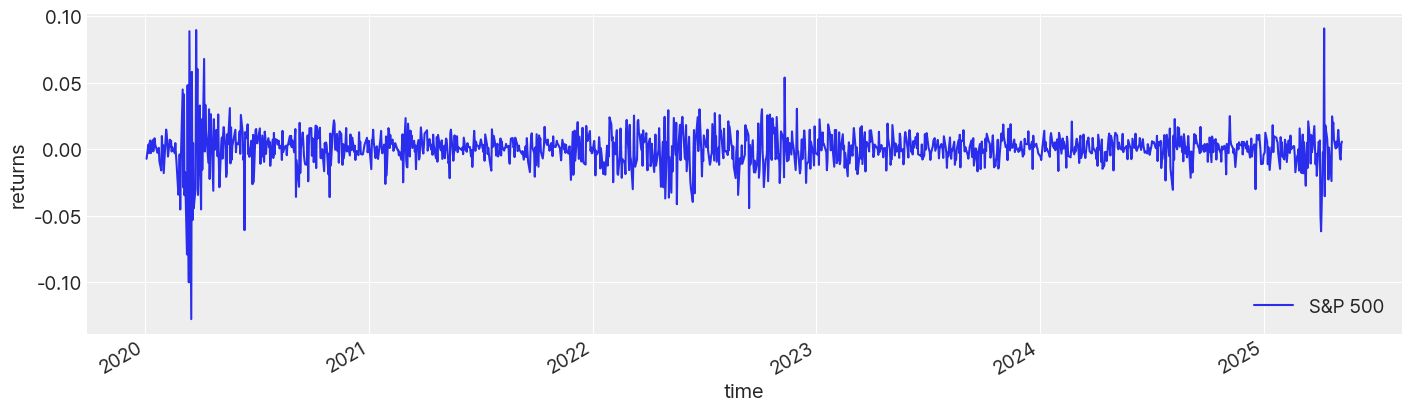

: 

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
returns.plot(y="logchange", label="S&P 500", ax=ax)
ax.set(xlabel="time", ylabel="returns")
ax.legend();

In [ ]:
def make_stochastic_volatility_model(data):
    with pm.Model(coords={"time": data.index.values}) as model:
        step_size = pm.Exponential("step_size", 10)
        volatility = pm.GaussianRandomWalk("volatility", sigma=step_size, dims="time")
        nu = pm.Exponential("nu", 0.1)
        returns = pm.StudentT(
            "returns", nu=nu, lam=np.exp(-2 * volatility), observed=data["logchange"], dims="time"
        )
    return model


stochastic_vol_model = make_stochastic_volatility_model(returns)

/opt/conda/envs/bap3/lib/python3.11/site-packages/pymc/distributions/timeseries.py:293: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100)`.You can specify an init_dist manually to suppress this warning.
  warnings.warn(


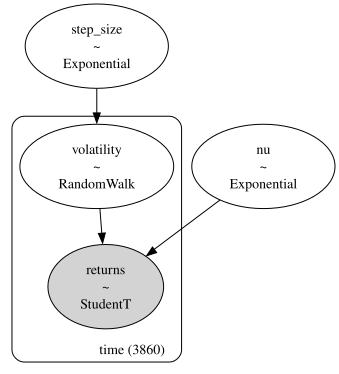

In [55]:
pm.model_to_graphviz(stochastic_vol_model)

In [56]:
rng = np.random.RandomState(1234)
az.style.use("arviz-darkgrid")

In [57]:
with stochastic_vol_model:
    idata = pm.sample_prior_predictive(500, random_seed=rng)

prior_predictive = idata.prior_predictive.stack(pooled_chain=("chain", "draw"))

Sampling: [nu, returns, step_size, volatility]


In [58]:
idata

Inference data with groups:
	> prior
	> prior_predictive
	> observed_data

In [59]:
prior_predictive

<xarray.Dataset>
Dimensions:       (time: 3860, pooled_chain: 500)
Coordinates:
  * time          (time) datetime64[ns] 2010-01-05 2010-01-06 ... 2025-05-08
  * pooled_chain  (pooled_chain) object MultiIndex
  * chain         (pooled_chain) int64 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
  * draw          (pooled_chain) int64 0 1 2 3 4 5 6 ... 494 495 496 497 498 499
Data variables:
    returns       (time, pooled_chain) float64 7.807e+44 ... -1.479e-51
Attributes:
    created_at:                 2025-05-09T07:03:24.799373
    arviz_version:              0.16.1
    inference_library:          pymc
    inference_library_version:  5.8.0

In [60]:
prior_predictive["returns"].shape

(3860, 500)

/tmp/ipykernel_17857/969553388.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


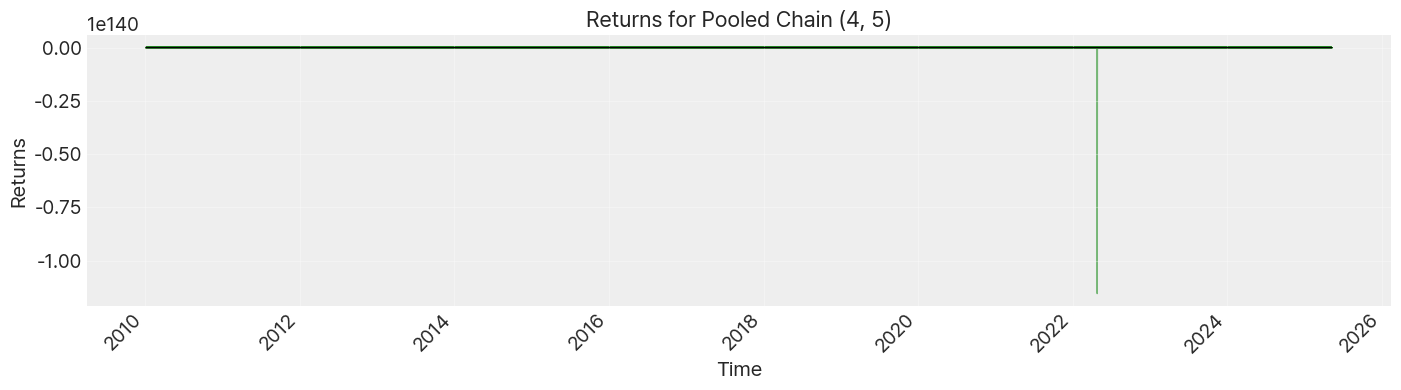

In [64]:

subset = prior_predictive["returns"].isel(pooled_chain=slice(None, None, 10))

# 그래프 그리기
fig, ax = plt.subplots(figsize=(14, 4))
returns["change"].plot(ax=ax, lw=1, color="black")
for i in range(subset.pooled_chain.size):
    chain, draw = subset.pooled_chain.values[i]
    label = f"Chain {chain}, Draw {draw}"
    plt.plot(subset.time, subset[:, i], label=label, color="g",
    alpha=0.5,
    lw=1,
    zorder=-10,)

plt.title("Returns for Pooled Chain (4, 5)")
plt.xlabel("Time")
plt.ylabel("Returns")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [65]:
with stochastic_vol_model:
    idata.extend(pm.sample(3000, random_seed=rng, target_accept=0.95, idata_kwargs={"log_likelihood": True}))

posterior = idata.posterior.stack(pooled_chain=("chain", "draw"))
# posterior["volatility"] = np.exp(posterior["volatility"])

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [step_size, volatility, nu]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1724 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [66]:
posterior["volatility"]

<xarray.DataArray 'volatility' (time: 3860, pooled_chain: 12000)>
array([[-4.64649468, -5.10771334, -4.70589839, ..., -4.94328578,
        -5.00812642, -4.95350807],
       [-4.63702623, -5.07246619, -4.62305486, ..., -4.83807526,
        -4.88339051, -5.05038329],
       [-4.65839   , -5.11061197, -4.56823545, ..., -4.83791134,
        -4.92612997, -5.10218538],
       ...,
       [-4.61697666, -4.298358  , -4.38797293, ..., -3.76666783,
        -4.21673442, -3.94019642],
       [-4.62177068, -4.20793064, -4.6643539 , ..., -3.89255598,
        -4.23258334, -4.03647263],
       [-4.52804097, -4.1452038 , -4.52801902, ..., -3.86717596,
        -4.24691436, -4.09681417]])
Coordinates:
  * time          (time) datetime64[ns] 2010-01-05 2010-01-06 ... 2025-05-08
  * pooled_chain  (pooled_chain) object MultiIndex
  * chain         (pooled_chain) int64 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3
  * draw          (pooled_chain) int64 0 1 2 3 4 5 ... 2995 2996 2997 2998 2999

In [67]:
posterior

<xarray.Dataset>
Dimensions:       (time: 3860, pooled_chain: 12000)
Coordinates:
  * time          (time) datetime64[ns] 2010-01-05 2010-01-06 ... 2025-05-08
  * pooled_chain  (pooled_chain) object MultiIndex
  * chain         (pooled_chain) int64 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3
  * draw          (pooled_chain) int64 0 1 2 3 4 5 ... 2995 2996 2997 2998 2999
Data variables:
    volatility    (time, pooled_chain) float64 -4.646 -5.108 ... -4.247 -4.097
    step_size     (pooled_chain) float64 0.1073 0.1075 0.1074 ... 0.1025 0.1048
    nu            (pooled_chain) float64 10.98 11.44 12.64 ... 14.58 12.9 13.66
Attributes:
    created_at:                 2025-05-09T07:33:34.071093
    arviz_version:              0.16.1
    inference_library:          pymc
    inference_library_version:  5.8.0
    sampling_time:              1723.9337937831879
    tuning_steps:               1000

In [68]:
idata

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> prior
	> prior_predictive
	> observed_data

In [69]:
summary = az.summary(idata)
summary[summary["r_hat"] > 1.0].sort_values("r_hat", ascending=False)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
step_size,0.102,0.008,0.086,0.117,0.001,0.0,137.0,298.0,1.04


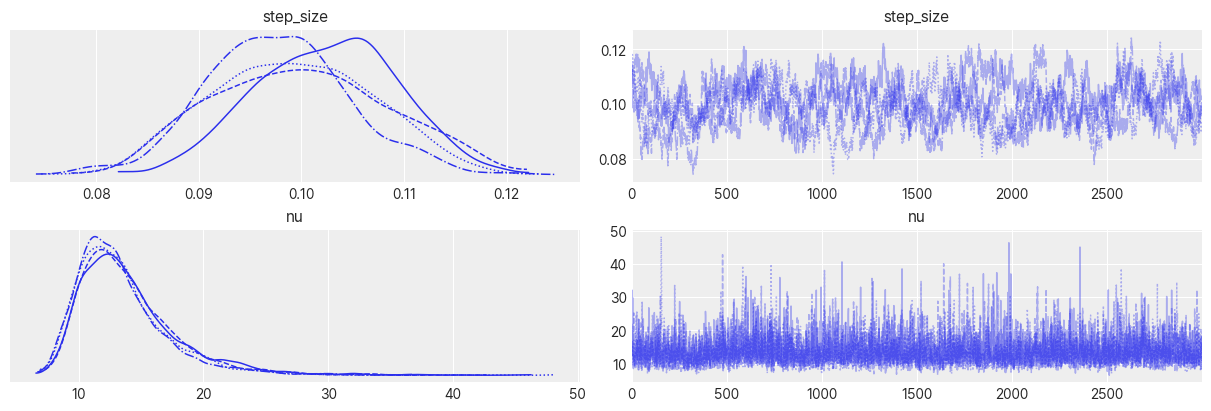

In [17]:
az.plot_trace(idata, var_names=["step_size", "nu"]);

In [70]:
az.loo(idata)

/opt/conda/envs/bap3/lib/python3.11/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 12000 posterior samples and 3860 observations log-likelihood matrix.

         Estimate       SE
elpd_loo 12935.09    59.03
p_loo      230.72        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.5]   (good)     3836   99.4%
 (0.5, 0.7]   (ok)         23    0.6%
   (0.7, 1]   (bad)         1    0.0%
   (1, Inf)   (very bad)    0    0.0%

In [71]:
with stochastic_vol_model:
    posterior_predictive = pm.sample_posterior_predictive(idata, random_seed=rng)

# posterior_predictive = posterior_predictive.stack(pooled_chain=("chain", "draw"))

Sampling: [returns]


In [72]:
posterior_predictive

Inference data with groups:
	> posterior_predictive
	> observed_data

In [73]:
posterior_predictive.posterior_predictive["returns"].shape

(4, 3000, 3860)

(-0.05, 0.05)

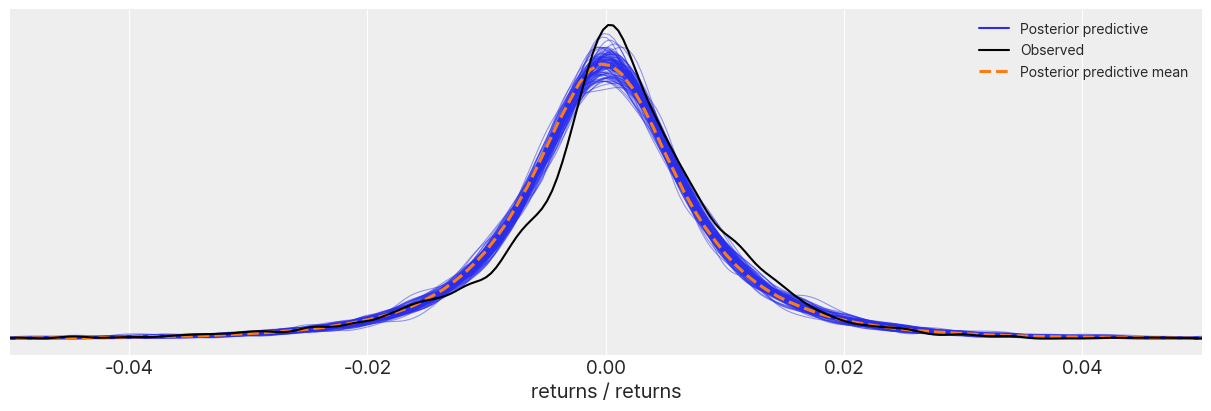

In [75]:
fig, ax = plt.subplots(figsize=(12, 4))
az.plot_ppc(posterior_predictive, num_pp_samples=100, ax=ax, kind="kde", alpha=0.5);
ax.set_xlim(-0.05, 0.05)

<Axes: title={'center': 'returns / returns'}>

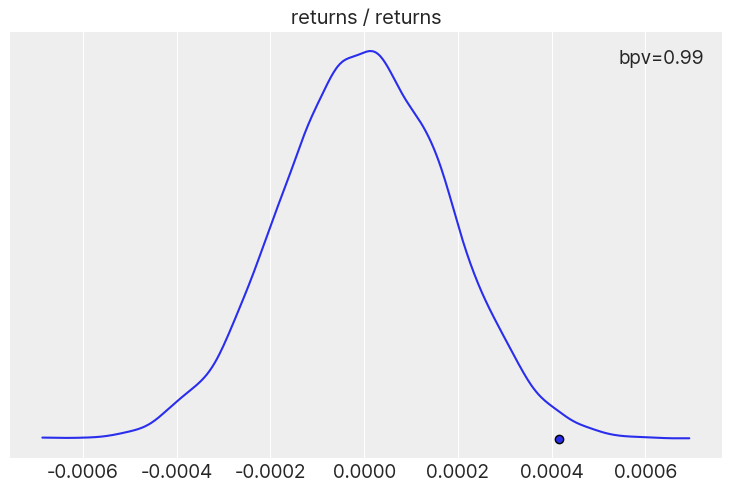

In [76]:
az.plot_bpv(posterior_predictive, kind="t_stat", t_stat="mean")

In [77]:
posterior

<xarray.Dataset>
Dimensions:       (time: 3860, pooled_chain: 12000)
Coordinates:
  * time          (time) datetime64[ns] 2010-01-05 2010-01-06 ... 2025-05-08
  * pooled_chain  (pooled_chain) object MultiIndex
  * chain         (pooled_chain) int64 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3
  * draw          (pooled_chain) int64 0 1 2 3 4 5 ... 2995 2996 2997 2998 2999
Data variables:
    volatility    (time, pooled_chain) float64 -4.646 -5.108 ... -4.247 -4.097
    step_size     (pooled_chain) float64 0.1073 0.1075 0.1074 ... 0.1025 0.1048
    nu            (pooled_chain) float64 10.98 11.44 12.64 ... 14.58 12.9 13.66
Attributes:
    created_at:                 2025-05-09T07:33:34.071093
    arviz_version:              0.16.1
    inference_library:          pymc
    inference_library_version:  5.8.0
    sampling_time:              1723.9337937831879
    tuning_steps:               1000

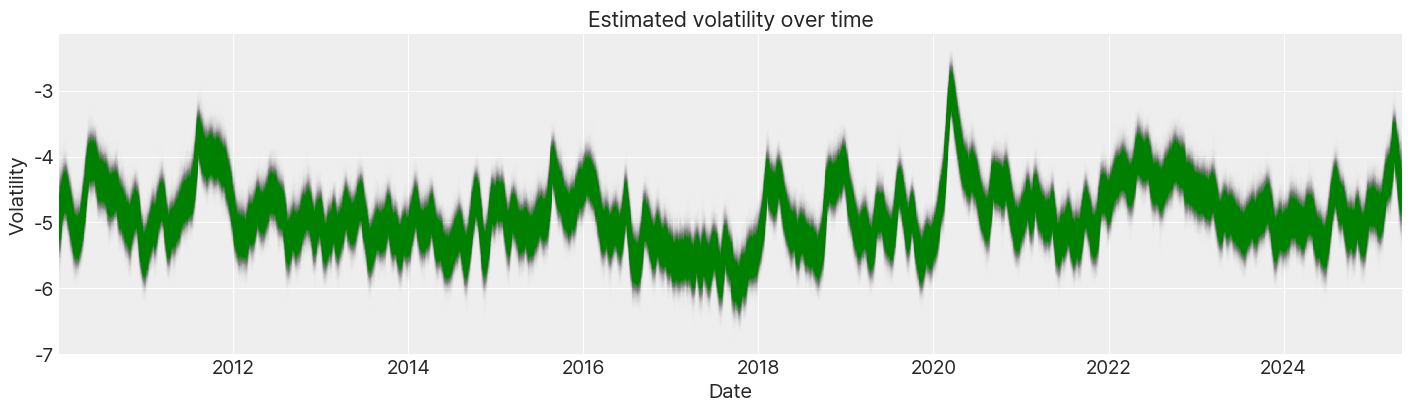

In [78]:
fig, ax = plt.subplots(figsize=(14, 4))

y_vals = posterior["volatility"].isel(pooled_chain=slice(None, None, 10))
x_vals = y_vals.time.astype(np.datetime64)

plt.plot(x_vals, y_vals, "g", alpha=0.002)
ax.set_xlim(x_vals.min(), x_vals.max())
# ax.set_ylim(bottom=0)
ax.set(title="Estimated volatility over time", xlabel="Date", ylabel="Volatility");

(20069.0, 20216.0)

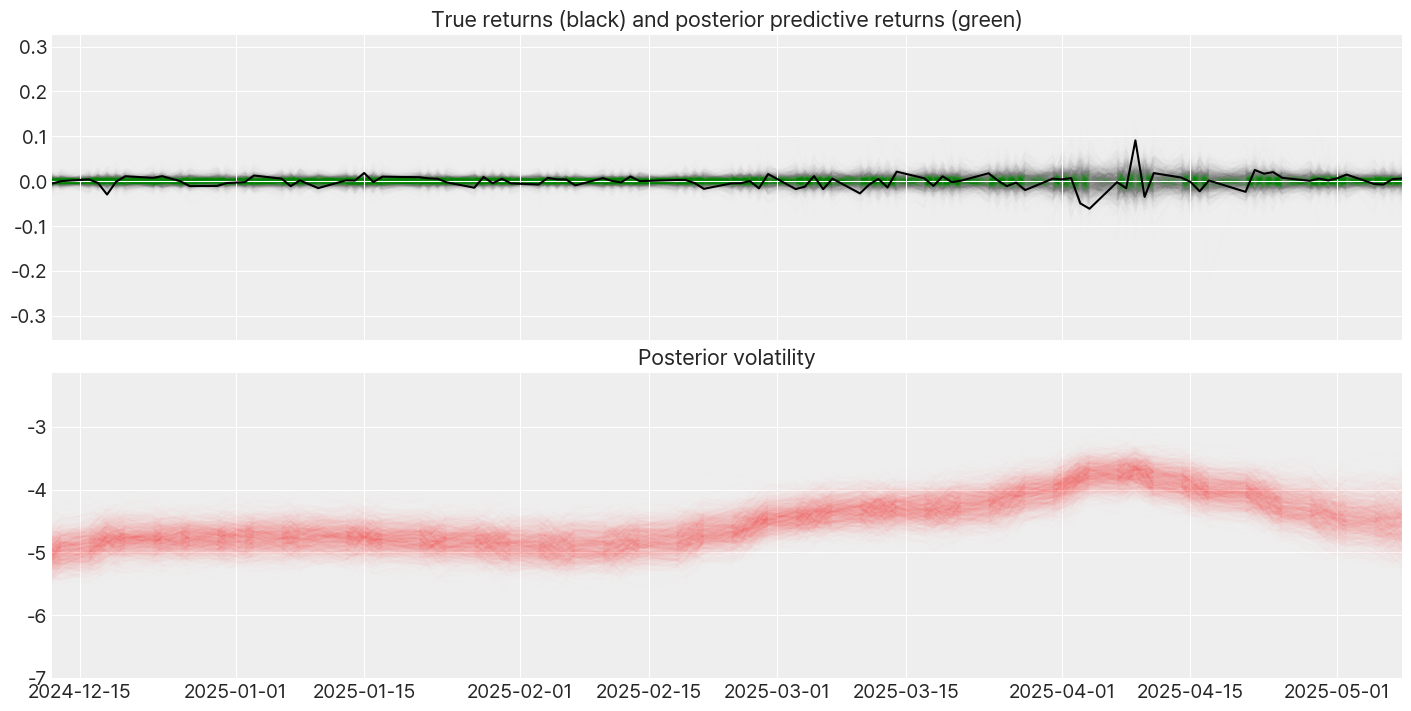

In [80]:
fig, axes = plt.subplots(nrows=2, figsize=(14, 7), sharex=True)
returns["change"].plot(ax=axes[0], color="black")

y_vals = posterior["volatility"].isel(pooled_chain=slice(None, None, 10))
x_vals = y_vals.time.astype(np.datetime64)
axes[1].plot(x_vals, y_vals, "r", alpha=0.002)

y_vals = posterior_predictive.posterior_predictive["returns"].stack(pooled_chain=("chain", "draw")).isel(pooled_chain=slice(None, None, 10))
# y_vals = np.exp(y_vals) - 1
x_vals = y_vals.time.astype(np.datetime64)
axes[0].plot(x_vals, y_vals, "g", alpha=0.002,
    zorder=-10)
axes[0].set_title("True returns (black) and posterior predictive returns (green)")
axes[1].set_title("Posterior volatility");
plt.xlim(x_vals[-100], x_vals.max())

In [ ]:
# 예측할 미래 시점 개수
n_forecast = 30

# 전체 시점 구성 (과거 + 미래)
future_dates = pd.date_range(start=data.index[-1] + pd.Timedelta(days=1), periods=n_forecast)
all_dates = data.index.union(future_dates)

with pm.Model(coords={"time": future_dates}) as model:
    step_size = pm.Exponential("step_size", 10)
    volatility = pm.GaussianRandomWalk("volatility", sigma=step_size, dims="time")
    nu = pm.Exponential("nu", 0.1)
    returns_forecast = pm.StudentT(
        "returns_forecast", nu=nu, lam=np.exp(-2 * volatility), dims="time",
        init_dist=pm.DiracDelta.dist(returns.changes[-1]),
    )

    pp = pm.sample_posterior_predictive(
        idata, 
        var_names=["returns_forecast"], 
        predictions=True, 
        random_seed=rng,
    )


/opt/conda/envs/bap3/lib/python3.11/site-packages/pymc/distributions/timeseries.py:293: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100)`.You can specify an init_dist manually to suppress this warning.
  warnings.warn(


KeyError: -1